# Exercise 7.5 — Phase Space of the SI Model (SIR without R)

**Textbook:** Sayama, *Introduction to the Modeling and Analysis of Complex Systems*, Section 7.2

---

## Model

$$\frac{dS}{dt} = -aSI \tag{7.22}$$

$$\frac{dI}{dt} = aSI - bI \tag{7.23}$$

$$S \geq 0, \quad I \geq 0, \quad a > 0, \quad b > 0 \tag{7.24}$$

$S$ = susceptible population, $I$ = infected population, $a$ = infection rate, $b$ = recovery rate.

---

## Step 1 — Nullclines

**$S$-nullclines** ($dS/dt = 0$):

$$-aSI = 0 \quad \Rightarrow \quad S = 0 \quad \text{or} \quad I = 0$$

**$I$-nullclines** ($dI/dt = 0$):

$$aSI - bI = I(aS - b) = 0 \quad \Rightarrow \quad I = 0 \quad \text{or} \quad S = \frac{b}{a}$$

So there are three nullcline curves in the $(S, I)$ plane:

| Curve | Type | Meaning |
|---|---|---|
| $I = 0$ | Both $S$- and $I$-nullcline | The $S$-axis — no infected individuals |
| $S = 0$ | $S$-nullcline | The $I$-axis — no susceptibles left |
| $S = b/a$ | $I$-nullcline | Epidemic threshold — infections neither grow nor shrink |

The vertical line $S = b/a$ is the key threshold: it is often written as $S = 1/R_0$ where $R_0 = aS_0/b$ is the basic reproduction number.

---

## Step 2 — Direction of Flow in Each Region

The nullclines $I = 0$ and $S = b/a$ divide the first quadrant into two regions:

**Region 1: $S > b/a$, $I > 0$**
- $dS/dt = -aSI < 0$ → $S$ is decreasing
- $dI/dt = I(aS - b) > 0$ → $I$ is increasing (since $aS > b$)
- Flow direction: **left and up** (epidemic growing)

**Region 2: $0 < S < b/a$, $I > 0$**
- $dS/dt = -aSI < 0$ → $S$ is decreasing
- $dI/dt = I(aS - b) < 0$ → $I$ is decreasing (since $aS < b$)
- Flow direction: **left and down** (epidemic dying out)

**Key insight:** Whether $I$ ever rises or only falls depends entirely on whether the initial susceptible population $S_0$ is above or below the threshold $b/a$.

---

## Step 3 — Equilibria

Setting both derivatives to zero simultaneously: the only solutions are points where $I = 0$ (and $S$ is anything $\geq 0$). So every point on the $S$-axis is an equilibrium. There are **no interior equilibria** — the infection either burns through the population or dies out, always landing back on the $S$-axis with $I = 0$ and some remaining susceptibles $S^* \in (0, S_0)$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [2]:
# Parameters
a = 0.3   # infection rate
b = 0.1   # recovery rate
threshold = b / a   # S = b/a  (epidemic threshold)

def model(t, state):
    S, I = state
    dS = -a * S * I
    dI =  a * S * I - b * I
    return [dS, dI]

print(f"Epidemic threshold  S = b/a = {threshold:.3f}")
print(f"Epidemics grow when S₀ > {threshold:.3f}, decline immediately when S₀ < {threshold:.3f}")

Epidemic threshold  S = b/a = 0.333
Epidemics grow when S₀ > 0.333, decline immediately when S₀ < 0.333


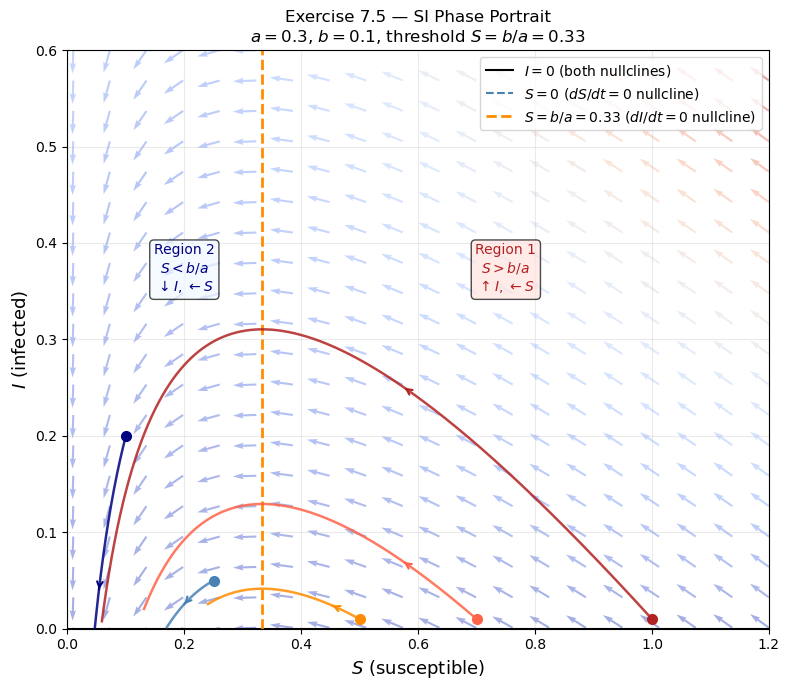

In [3]:
# --- Phase portrait with nullclines, vector field, and trajectories ---

fig, ax = plt.subplots(figsize=(8, 7))

S_max, I_max = 1.2, 0.6

# --- Vector field ---
Sg, Ig = np.meshgrid(np.linspace(0.01, S_max, 20), np.linspace(0.001, I_max, 20))
dS = -a * Sg * Ig
dI =  a * Sg * Ig - b * Ig
norm = np.sqrt(dS**2 + dI**2)
norm[norm == 0] = 1
ax.quiver(Sg, Ig, dS / norm, dI / norm, norm, cmap='coolwarm', alpha=0.45, scale=30)

# --- Nullclines ---
# I = 0 is the S-axis (both nullclines)
ax.axhline(0, color='black', linewidth=1.5, linestyle='-', label='$I = 0$ (both nullclines)')
# S = 0 is the I-axis (S-nullcline)
ax.axvline(0, color='steelblue', linewidth=1.5, linestyle='--', label='$S = 0$ ($dS/dt=0$ nullcline)')
# S = b/a (I-nullcline)
ax.axvline(threshold, color='darkorange', linewidth=2, linestyle='--',
           label=f'$S = b/a = {threshold:.2f}$ ($dI/dt=0$ nullcline)')

# --- Region labels ---
ax.text(0.75, 0.35, 'Region 1\n$S > b/a$\n$\\uparrow I$, $\\leftarrow S$',
        fontsize=10, ha='center', color='firebrick',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='mistyrose', alpha=0.7))
ax.text(0.2, 0.35, 'Region 2\n$S < b/a$\n$\\downarrow I$, $\\leftarrow S$',
        fontsize=10, ha='center', color='navy',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='aliceblue', alpha=0.7))

# --- Trajectories ---
t_span = (0, 80)
t_eval = np.linspace(0, 80, 5000)

initial_conditions = [
    (1.0, 0.01),   # S0 >> threshold → big epidemic
    (0.7, 0.01),   # S0 > threshold → moderate epidemic
    (0.5, 0.01),   # S0 > threshold → small epidemic
    (0.25, 0.05),  # S0 < threshold → immediate decline
    (0.1, 0.2),    # well below threshold
]
traj_colors = ['firebrick', 'tomato', 'darkorange', 'steelblue', 'navy']

for (S0, I0), color in zip(initial_conditions, traj_colors):
    sol = solve_ivp(model, t_span, [S0, I0], t_eval=t_eval, rtol=1e-9, atol=1e-11)
    ax.plot(sol.y[0], sol.y[1], color=color, linewidth=1.8, alpha=0.85)
    ax.plot(S0, I0, 'o', color=color, markersize=7)
    # arrow at ~25% along
    idx = len(sol.t) // 4
    ax.annotate('', xy=(sol.y[0][idx+5], sol.y[1][idx+5]),
                xytext=(sol.y[0][idx], sol.y[1][idx]),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5))

ax.set_xlim(0, S_max)
ax.set_ylim(0, I_max)
ax.set_xlabel('$S$ (susceptible)', fontsize=13)
ax.set_ylabel('$I$ (infected)', fontsize=13)
ax.set_title('Exercise 7.5 — SI Phase Portrait\n'
             f'$a={a}$, $b={b}$, threshold $S=b/a={threshold:.2f}$', fontsize=12)
ax.legend(fontsize=10, loc='upper right')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

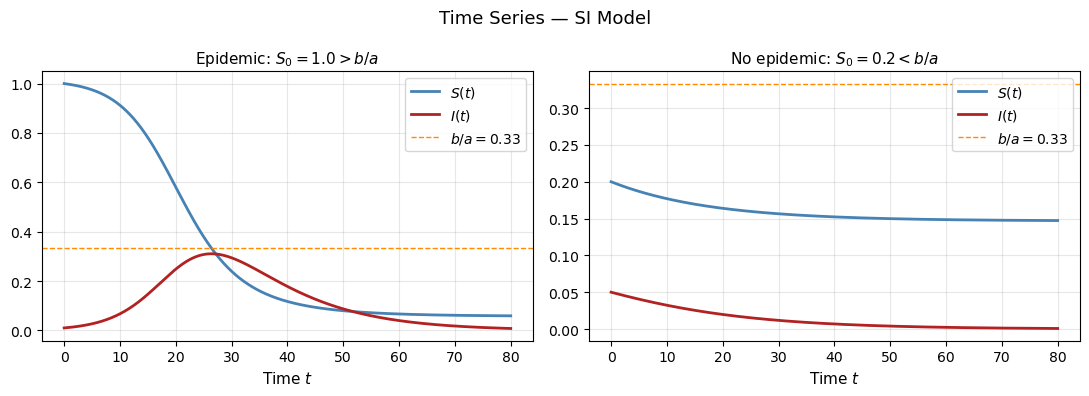

: 

In [ ]:
# --- Time series for two contrasting cases ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)
cases = [(1.0, 0.01, 'Epidemic: $S_0 = 1.0 > b/a$'), (0.2, 0.05, 'No epidemic: $S_0 = 0.2 < b/a$')]

for ax, (S0, I0, title) in zip(axes, cases):
    sol = solve_ivp(model, t_span, [S0, I0], t_eval=t_eval, rtol=1e-9)
    ax.plot(sol.t, sol.y[0], label='$S(t)$', color='steelblue', linewidth=2)
    ax.plot(sol.t, sol.y[1], label='$I(t)$', color='firebrick', linewidth=2)
    ax.axhline(threshold, color='darkorange', linestyle='--', linewidth=1,
               label=f'$b/a = {threshold:.2f}$')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Time $t$', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

fig.suptitle('Time Series — SI Model', fontsize=13)
plt.tight_layout()
plt.show()

---

## Summary

| | |
|---|---|
| **$S$-nullclines** | $S = 0$ and $I = 0$ |
| **$I$-nullclines** | $I = 0$ and $S = b/a$ |
| **Equilibria** | Every point $(S^*, 0)$, $S^* \geq 0$ — the entire $S$-axis |
| **Region $S > b/a$, $I > 0$** | $I$ rises, $S$ falls → epidemic grows then turns over |
| **Region $S < b/a$, $I > 0$** | Both $I$ and $S$ fall → epidemic immediately dies out |
| **Epidemic threshold** | $S_0 > b/a$ is required for an outbreak; equivalently $R_0 = aS_0/b > 1$ |

All trajectories curve leftward (S always decreasing whenever I > 0) and eventually land on the S-axis with some susceptibles still remaining — the epidemic runs out of steam before infecting everyone.